# Assignment M3
**George Khramtchenko - University of Connecticut**

-------------------------------------
The work contained and presented here is my work and my work alone. The following sources were used:
*   OPIM 5604 Module 2 Preprocessing.ipynb
*   KhramtchenkoGeorgeOPIM5604AssignmentM3.ipynb
*   https://hex.tech/blog/comparing-density-based-methods
*   Google Gemini
*   StackOverflow


# Environment Setup

In [79]:
# import modules

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

!pip install scikit-learn
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Set display options to show all columns
pd.set_option('display.max_columns', None)

In [80]:
# Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Prompt 1:** Read in the dataset and determine how many rows and columns it has

In [81]:
# Initially, an encoding error prevented the code from running due to an issue with reading the encoding. Encoding handling was added for 'latin-1'.
try:
    df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Module 3/Assignment M3/spotify-2023.csv', encoding='latin-1')
    # Obtain the number of rows and columns this data has
    print(df.shape)

except UnicodeDecodeError:
    print("UnicodeDecodeError: Failed to decode the file using 'latin-1' encoding.")

(953, 24)


This dataset has **953** rows and **24** columns.

Print the head elements of each column row for initial data visualization.

In [82]:
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year  released_month  released_day  in_spotify_playlists  \
0           2023               7            14                   553   
1           2023               3            23                  1474   
2           2023               6            30                  1397   
3           2019               8            23                  7858   
4           2023               5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  in_apple_charts  \
0                147  141381703                  4

**Prompt 2:** The target variable for this dataset is the streams column.  Check the datatype of streams.  If it isn’t already int64, update it.  Hint: if needed, drop a row of problematic data to get it to convert properly.

In [83]:
# View the data types of the columns
print(f"View the data types of the columns before any required changes are implemented, if necessary: \n{df.dtypes}")

# Previous code block execution attempts had failed and yielded row(s) of problematic data
# Locate and remove the problematic row(s) of data before type conversion from obj to int86
# Utilizing the 'errors='coerce' allows the missing data to be converted into a NaN without raising an exception
problematic_rows = df[pd.to_numeric(df['streams'], errors='coerce').isna()]
if not problematic_rows.empty:
    print(f"\nFound problematic row(s) in 'streams' column: {problematic_rows}")
    df.drop(problematic_rows.index, inplace=True)
    print(f"\nDropped {len(problematic_rows)} problematic row(s).")

# Once all rows with the problematic data have been dropped,
# attempt conversion from 'object' to 'int64' for the 'streams' column
# Display the data type of the 'streams' column and the head for verification
try:
    df['streams'] = df['streams'].astype('int64')
    print(f"\nUpon data correction, the 'streams' column was successfully converted to type: {df['streams'].dtypes}.")
    print(f"View the head of the 'streams' column: \n{df['streams'].head()}")

# Basic error handling
except ValueError as vr:
    print(f"\n Conversion of 'streams' column to int64 after dropping problematic row(s) failed: {vr}")

View the data types of the columns before any required changes are implemented, if necessary: 
track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
dtype: object

Found problematic row(s) in 'streams' column:                               track_name     artist(s)_name  artist_count  \
574  Love Grows (Where 

**Prompt 3:** Perform hierarchical clustering on danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveliness_%, and speechiness_%.

In [84]:
# Select the columns for clustering.
# Let's use the same columns as the manual calculation.
cols_for_clustering = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
df_clustering = df[cols_for_clustering]

# Standardize the data.
# It's important to standardize features before hierarchical clustering
# as distance metrics are sensitive to scale.
scaler = StandardScaler()
df_scaled_clustering = scaler.fit_transform(df_clustering)

# Convert the scaled data back to a pandas DataFrame for easier handling (optional but good practice)
# Use the original column names
df_scaled_clustering = pd.DataFrame(df_scaled_clustering, columns=cols_for_clustering)

# Print the first few rows of the dataframe to verify that the data is standardized
print(df_scaled_clustering.head())

   danceability_%  valence_%  energy_%  acousticness_%  instrumentalness_%  \
0        0.890052   1.601891  1.131483        0.150886           -0.188234   
1        0.274608   0.408787  0.587671       -0.772619           -0.188234   
2       -1.093045  -0.826928 -0.681226       -0.387825           -0.188234   
3       -0.819514   0.280954  0.466823       -0.618702           -0.188234   
4       -0.135688  -1.210426  0.950212       -0.503264            7.303165   

   liveness_%  speechiness_%  
0   -0.744961      -0.619429  
1   -0.599095      -0.619429  
2    0.932504      -0.417616  
3   -0.526161       0.490540  
4   -0.526161      -0.417616  


Step 2 - Perform the clustering.

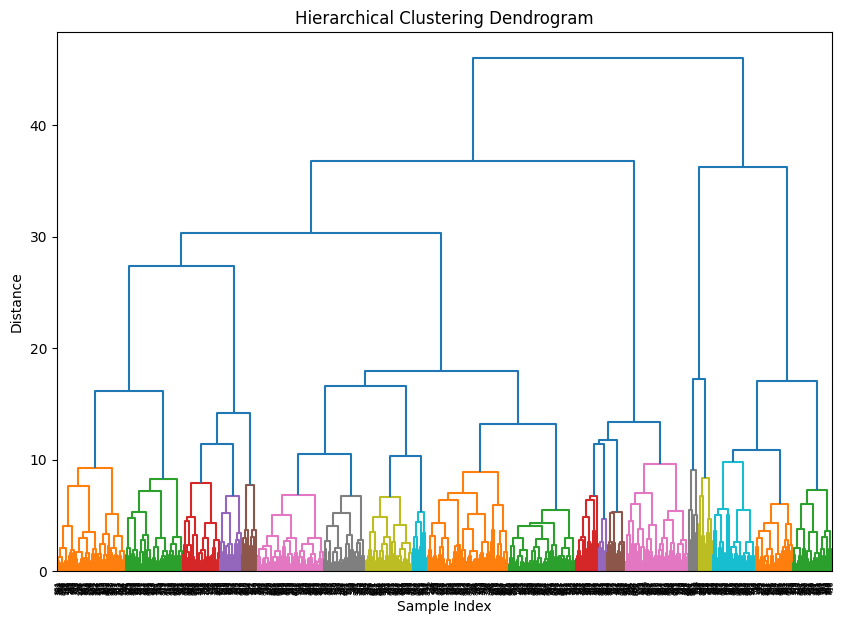

In [85]:
# Perform hierarchical clustering
# We will use the 'ward' linkage method which minimizes the variance of the clusters being merged.
# 'euclidean' is the default distance metric, which we have already used.
linked = linkage(df_scaled_clustering, 'ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=10) # optional color_threshold

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

Step 3 - Create a table to view the numbers. A dendogram is formed from this data.

In [86]:
# Print the distances used to generate the dendrogram
# The third column of the linkage matrix contains the distances at which merges occur.
distances = linked[:, 2]

# The linkage matrix 'linked' has shape (n-1, 4), where n is the number of original observations.
# Each row represents a merge. The third column (index 2) is the distance of the merge.
# The last column (index 3) is the number of original observations in the new cluster.

# We can sort the distances to see the order of merges
sorted_distances = np.sort(distances)
# print("\nSorted distances at which merges occurred:")
# print(sorted_distances)

# Let's create a DataFrame to show the distances and the number of clusters that would exist
# if we cut the dendrogram at that distance (approximately).
# The number of clusters starts at the number of data points (150) and decreases by 1 at each merge.
num_original_points = df_scaled_clustering.shape[0]
num_clusters_at_merge = np.arange(num_original_points - 1, 0, -1)

# Create a DataFrame with distances and corresponding number of clusters
distances_df = pd.DataFrame({
    'Merge Distance': sorted_distances,
    'Number of Clusters After Merge': num_clusters_at_merge
})

# Print the DataFrame
print("\nMerge Distances and Corresponding Number of Clusters:")
display(distances_df)

# You can examine this table and the dendrogram to help decide on a suitable number of clusters
# by looking for large jumps in the merge distance.


Merge Distances and Corresponding Number of Clusters:


,Merge Distance,Number of Clusters After Merge
0,0.000000,951
1,0.109534,950
2,0.121894,949
3,0.171729,948
4,0.179022,947
...,...,...
946,27.365854,5
947,30.300160,4
948,36.242580,3
949,36.810998,2


Step 4 - Plot merge distance versus the number of clusters to help pick the optimal number of clusters.

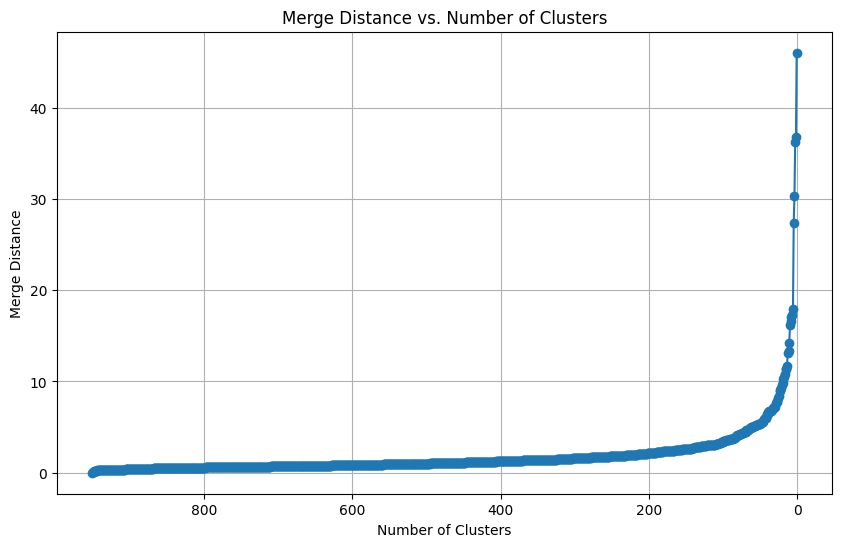

In [87]:
# Plot the distance and number of clusters
plt.figure(figsize=(10, 6))
plt.plot(distances_df['Number of Clusters After Merge'], distances_df['Merge Distance'], marker='o', linestyle='-')
plt.title('Merge Distance vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Merge Distance')
plt.grid(True)
plt.gca().invert_xaxis() # Invert x-axis so 1 cluster is on the right
plt.show()

For both the original and standardized data, save the cluster numbers for each row for 5 clusters.

In [88]:
# Get the cluster assignments for k=5
k = 5
clusters = fcluster(linked, t=k, criterion='maxclust')

# Assign the cluster labels to the dataframe
df['Cluster'] = clusters

# Print the first few rows of the dataframe to verify that the cluster labels have been assigned
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year  released_month  released_day  in_spotify_playlists  \
0           2023               7            14                   553   
1           2023               3            23                  1474   
2           2023               6            30                  1397   
3           2019               8            23                  7858   
4           2023               5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  in_apple_charts  \
0                147  141381703                  4

In [89]:
# Assign the cluster labels to the standardized dataframe
df_scaled_clustering['Cluster'] = clusters

# Print the first few rows of the dataframe to verify that the standardized data has the clusters added too
print(df_scaled_clustering.head())

   danceability_%  valence_%  energy_%  acousticness_%  instrumentalness_%  \
0        0.890052   1.601891  1.131483        0.150886           -0.188234   
1        0.274608   0.408787  0.587671       -0.772619           -0.188234   
2       -1.093045  -0.826928 -0.681226       -0.387825           -0.188234   
3       -0.819514   0.280954  0.466823       -0.618702           -0.188234   
4       -0.135688  -1.210426  0.950212       -0.503264            7.303165   

   liveness_%  speechiness_%  Cluster  
0   -0.744961      -0.619429        4  
1   -0.599095      -0.619429        4  
2    0.932504      -0.417616        4  
3   -0.526161       0.490540        4  
4   -0.526161      -0.417616        2  


**Prompt 3a:** How many clusters are you keeping and why? Justify your response with the dendrogram and the merge distance line chart.

**Answer:** To explore the characteristics of the clusters, I utilized the dendrogram and the merge distance line chart to determine how many clusters I would keep. I have decided to keep **6** clusters. This is because the distance between these clusters begins to become much more extensive compared to the historical average of approaching 50 or so clusters and contains significant, important data as the number of clusters shrinks and more data is efficiently clustered.

**Prompt 3b:** Produce the parallel plot for the cluster means.  Describe the notable attributes of each cluster and give each cluster a meaningful name.


Mean of Scaled Variables per Cluster:
         danceability_%  valence_%  energy_%  acousticness_%  \
Cluster                                                        
1             -0.758109  -0.501405 -1.310536        1.612318   
2             -0.529477  -0.904803 -0.418695        0.282247   
3              0.412849   0.020078 -0.058297       -0.019088   
4              0.365552   0.675786  0.560781       -0.370505   
5             -0.298861  -0.679176 -0.025899       -0.397054   

         instrumentalness_%  liveness_%  speechiness_%  
Cluster                                                 
1                 -0.114623   -0.256259      -0.461548  
2                  4.818333   -0.236943      -0.490686  
3                 -0.179680   -0.344091       1.996148  
4                 -0.143833   -0.104417      -0.308968  
5                 -0.169383    0.541451      -0.303174  

Number of Data Points per Cluster:
Cluster
1    147
2     29
3    139
4    391
5    246
Name: count, dtype: int6

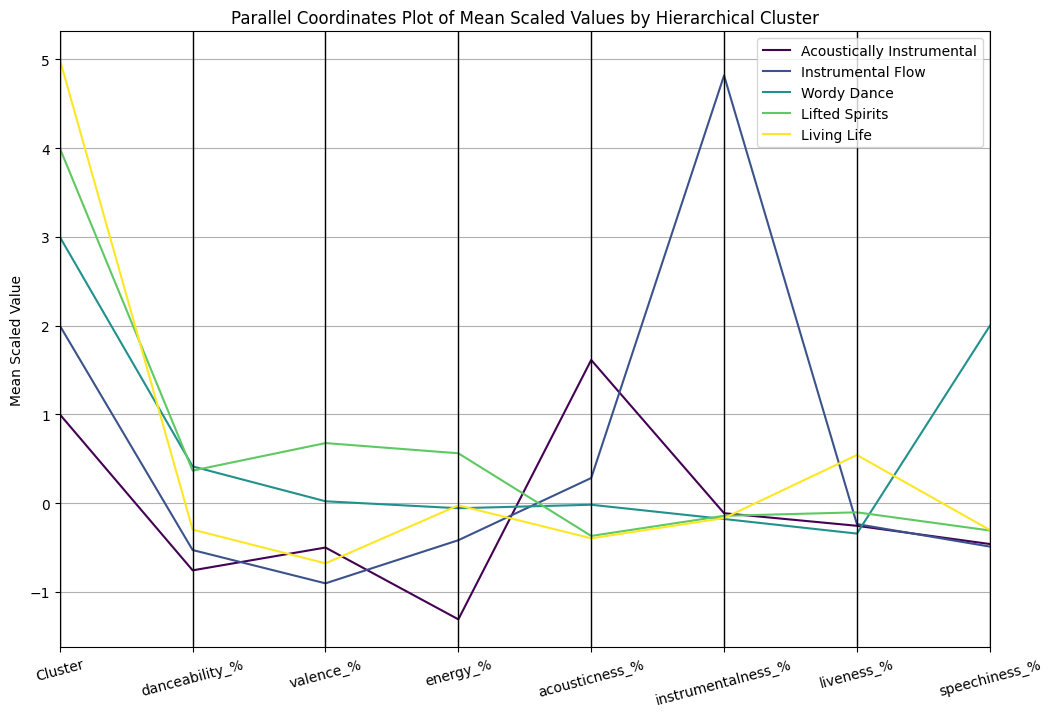

In [90]:
# Parallel Coordinates Plot
# The parallel coordinates plot is useful for visualizing the values of each variable
# for records belonging to different clusters. It helps see the profile of each cluster.
# It's best used with scaled data.

# Select the columns to plot (all numeric columns except 'Cluster')
cols_for_plotting = cols_for_clustering + ['Cluster'] # Include the Cluster column for coloring
df_plot = df_scaled_clustering[cols_for_plotting]

# To get a better sense of the cluster profiles, we can calculate the mean
# of the scaled variables for each cluster.
cluster_means_scaled = df_scaled_clustering.groupby('Cluster')[cols_for_clustering].mean()

print("\nMean of Scaled Variables per Cluster:")
print(cluster_means_scaled)

# Add cluster counts
cluster_counts = df_scaled_clustering['Cluster'].value_counts().sort_index()
print("\nNumber of Data Points per Cluster:")
print(cluster_counts)

# Define custom names for the hierarchical clusters
hierarchical_cluster_names = {
    1: 'Acoustically Instrumental',
    2: 'Instrumental Flow',
    3: 'Wordy Dance',
    4: 'Lifted Spirits',
    5: 'Living Life'
}

# Add a column with the custom cluster names to the cluster_means_scaled DataFrame
cluster_means_scaled['Cluster_Name'] = cluster_means_scaled.index.map(hierarchical_cluster_names)


# We can visualize these means on a parallel coordinates plot
plt.figure(figsize=(12, 8))
# Use cluster_means_scaled and the 'Cluster_Name' column for the class
parallel_coordinates(cluster_means_scaled.reset_index(), 'Cluster_Name', colormap=plt.get_cmap("viridis")) # Use reset_index() to make Cluster a column again

plt.title('Parallel Coordinates Plot of Mean Scaled Values by Hierarchical Cluster') # Updated title
plt.ylabel('Mean Scaled Value')
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

**Answer:** Cluster 1 has the lowest point of approximately -1.5, with a high point of 1.5. This means that the focus of this cluster is most pronounced on acousticness, with some instrumentality, liveness, and speechiness. Danceability and valence rank low. This cluster will be named **"Acoustically Instrumental**". Cluster 2 has the lowest point of valence, but with an instrumentality value of approximately 4.6, it has the highest mean scaled value of all present values. This cluster will be named **"Instrumental Flow"**. Cluster 3 has the highest combinations of danceability and speechiness and will be named **"Wordy Dance"**. Cluster 4 has the highest valence and energy and the second-highest danceability with the least acousticness. It will be known as **"Lifted Spirits"**. Cluster 5 has the most lively tracks but lacks in other categories. It will be known as **"Living Life"**.

**3c:** Produce row level parallel plots for each cluster and the biplot of the clusters.  Describe the observable variability within the clusters and between the clusters.

**Row-level parallel plots for each cluster displayed below.**

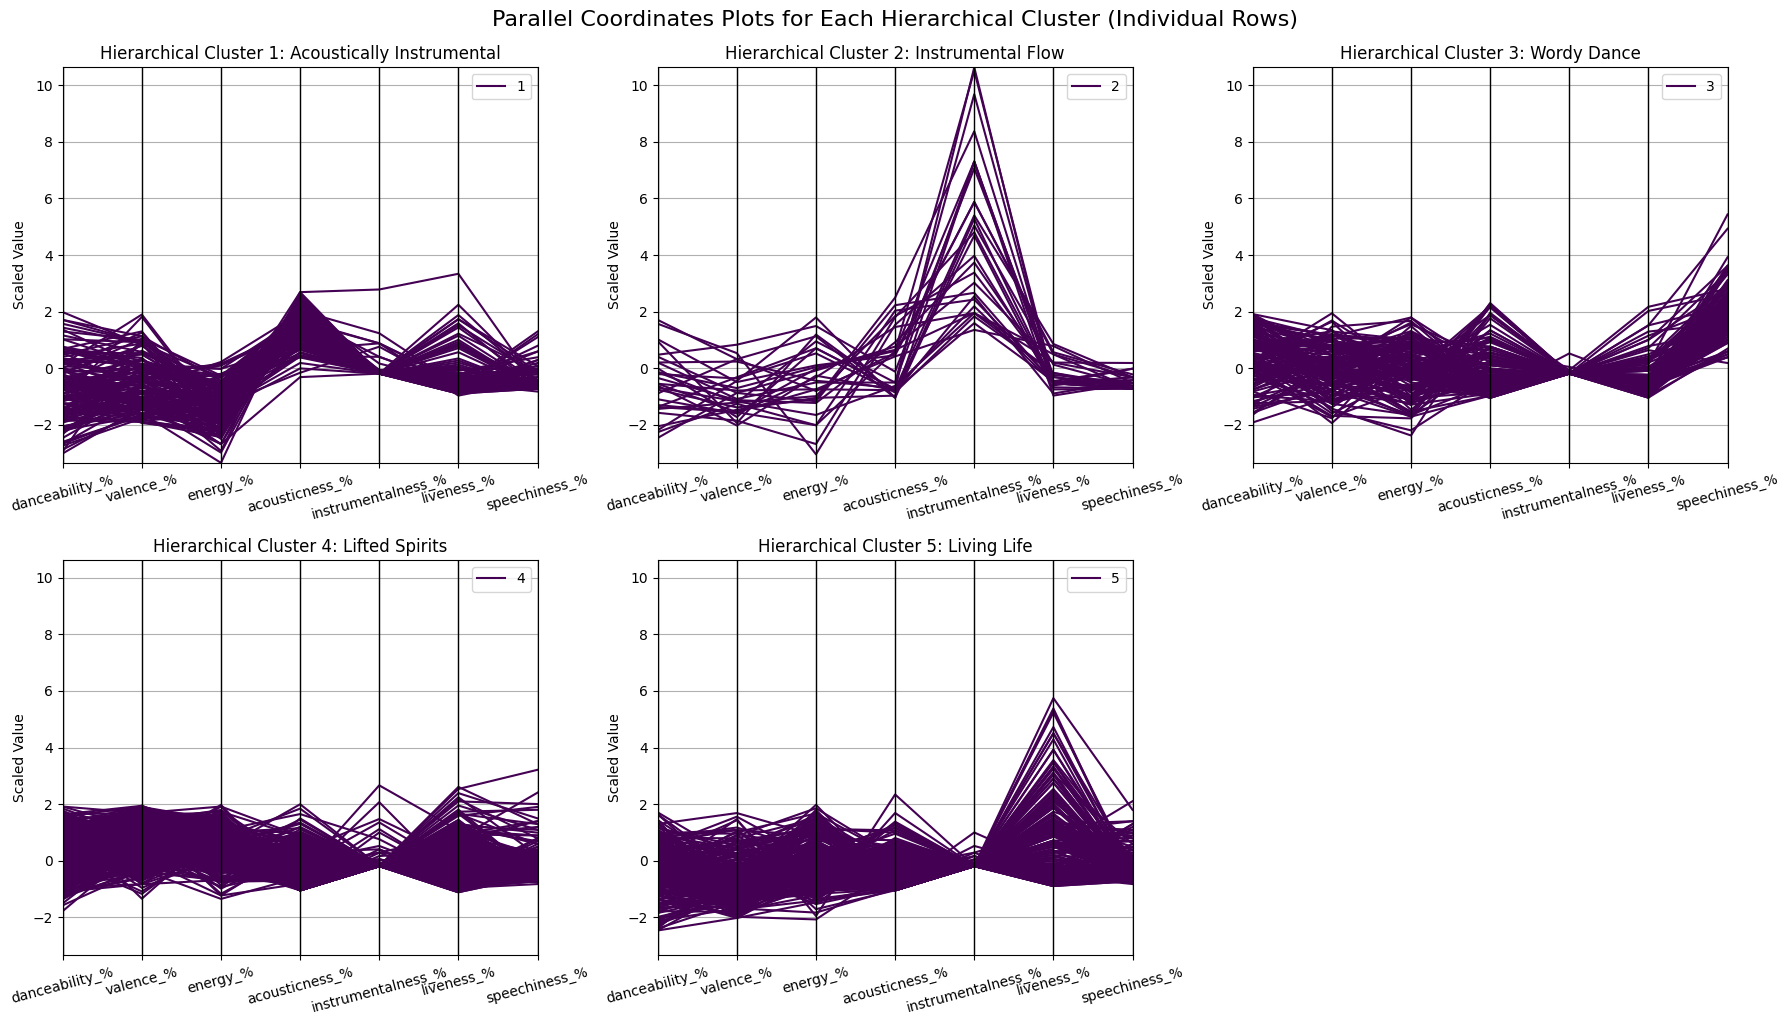

In [91]:
# To plot individual rows for each cluster, we need to select the columns for plotting,
# including the assigned 'Cluster' column.
cols_for_plotting_individual = cols_for_clustering + ['Cluster']
df_plot_individual = df_scaled_clustering[cols_for_plotting_individual].copy()

# We need to handle the index for the parallel coordinates plot function
# parallel_coordinates expects the 'class' column to be separate
# Let's iterate through each cluster and create a separate plot

unique_clusters = df_plot_individual['Cluster'].unique()
unique_clusters.sort() # Sort cluster numbers for order

# Determine the number of rows and columns for the subplot grid
n_clusters = len(unique_clusters)
n_cols = 3
n_rows = (n_clusters + n_cols - 1) // n_cols # Calculate number of rows needed

# Create a single figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the axes array for easier iteration

# Determine the global minimum and maximum values across all features and all data points for consistent y-axis
global_min = df_scaled_clustering[cols_for_clustering].values.min()
global_max = df_scaled_clustering[cols_for_clustering].values.max()

# Define custom names for the hierarchical clusters
hierarchical_cluster_names = {
    1: 'Acoustically Instrumental',
    2: 'Instrumental Flow',
    3: 'Wordy Dance',
    4: 'Lifted Spirits',
    5: 'Living Life'
}

for i, cluster_id in enumerate(unique_clusters):
    # Filter the dataframe for the current cluster
    df_cluster_subset = df_plot_individual[df_plot_individual['Cluster'] == cluster_id].copy()

    # The 'class' column (Cluster) needs to be the last column for parallel_coordinates
    # and we need to ensure the data columns are in the correct order
    data_cols = cols_for_clustering # Ensure data columns are in the original order
    df_cluster_subset = df_cluster_subset[data_cols + ['Cluster']]

    # Plot parallel coordinates for the individual rows in this cluster on the current subplot
    parallel_coordinates(df_cluster_subset, 'Cluster', colormap=plt.get_cmap("viridis"), ax=axes[i])

    # Set the title using the custom cluster names
    axes[i].set_title(f'Hierarchical Cluster {cluster_id}: {hierarchical_cluster_names.get(cluster_id, "Unknown Cluster")}')
    axes[i].set_ylabel('Scaled Value')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(True)
    axes[i].set_ylim(global_min, global_max) # Set the same y-axis limits for all subplots


# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent titles/labels overlapping
plt.suptitle('Parallel Coordinates Plots for Each Hierarchical Cluster (Individual Rows)', y=1.02, fontsize=16) # Add a main title
plt.show()

**The biplot of the clusters is displayed below.**

In [92]:
# Select the columns for distance calculation
cols_for_distance = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
df_distance = df[cols_for_distance]

# Standardize the data
# Using StandardScaler as requested
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_distance)

# Convert the scaled data back to a pandas DataFrame for easier handling (optional but good practice)
# Use the original column names
df_scaled = pd.DataFrame(df_scaled, columns=cols_for_distance)


# Calculate pairwise Euclidean distance matrix using the scaled data
n_rows = df_scaled.shape[0]
distance_matrix = np.zeros((n_rows, n_rows))

for i in range(n_rows):
    for j in range(n_rows):
        if i < j: # Calculate for the upper triangle to avoid redundant calculations and self-distance
            diff_sq = (df_scaled.iloc[i] - df_scaled.iloc[j])**2
            distance = np.sqrt(diff_sq.sum())
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance # Fill the lower triangle as the matrix is symmetric

# The distance_matrix now contains the pairwise Euclidean distances of the scaled data.
# For a small sample, you can print or inspect it. For larger data, this matrix can be very big.
print("Pairwise Euclidean Distance Matrix (after standardization):")
print(distance_matrix)

Pairwise Euclidean Distance Matrix (after standardization):
[[0.         1.72398962 4.03268836 ... 1.47342982 1.38112073 2.99316423]
 [1.72398962 0.         2.74629776 ... 1.16588012 0.83485446 1.51121609]
 [4.03268836 2.74629776 0.         ... 3.47445725 3.29717789 1.82401365]
 ...
 [1.47342982 1.16588012 3.47445725 ... 0.         0.9266399  2.50694654]
 [1.38112073 0.83485446 3.29717789 ... 0.9266399  0.         2.17471523]
 [2.99316423 1.51121609 1.82401365 ... 2.50694654 2.17471523 0.        ]]


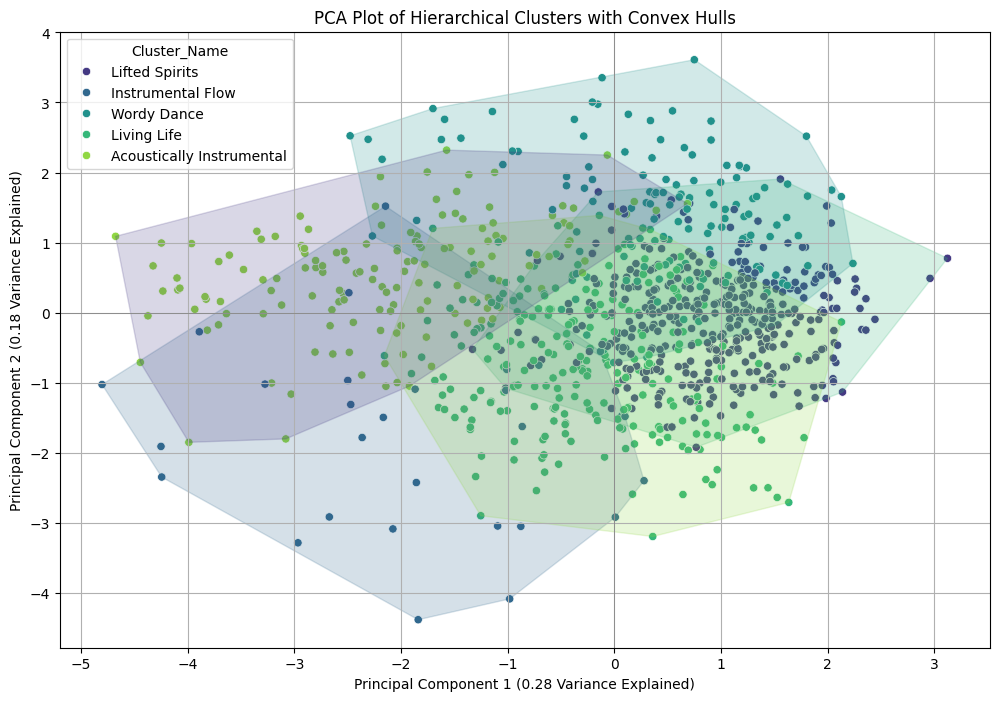

In [93]:
# Biplots using Principal Component Analysis (PCA)
# This helps visualize clusters in a reduced-dimensional space.

from sklearn.decomposition import PCA
# import matplotlib.patches as patches # Import patches for drawing ellipses - not needed for convex hull
from scipy.spatial import ConvexHull # Import ConvexHull
import matplotlib.patches as patches # Import patches for drawing polygons

# Use the scaled data used for hierarchical clustering
# This is df_scaled_clustering, excluding the 'Cluster' column which was added later
df_scaled_pca_input = df_scaled_clustering.drop(columns=['Cluster'])

# Perform PCA - let's keep 2 components for a 2D biplot
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled_pca_input)

# Create a DataFrame with the principal components
df_principal_components = pd.DataFrame(data=principal_components, columns=['principal_component_1', 'principal_component_2'])

# Add the hierarchical cluster labels to the PCA dataframe
# Ensure the index aligns with the original scaled data before PCA
df_principal_components['Cluster'] = df_scaled_clustering['Cluster']

# Define custom names for the hierarchical clusters
hierarchical_cluster_names = {
    1: 'Acoustically Instrumental',
    2: 'Instrumental Flow',
    3: 'Wordy Dance',
    4: 'Lifted Spirits',
    5: 'Living Life'
}

# Add a column with the custom cluster names to the PCA dataframe for plotting
df_principal_components['Cluster_Name'] = df_principal_components['Cluster'].map(hierarchical_cluster_names)

# --- Plotting the Biplot ---
plt.figure(figsize=(12, 8))
ax = plt.gca() # Get the current axes for adding patches

# Create a scatter plot of the data points in the PCA space, colored by cluster name for the legend
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='Cluster_Name', data=df_principal_components, palette='viridis', legend='full', ax=ax)

# Add Convex Hulls for each cluster
for cluster_id in df_principal_components['Cluster'].unique():
    # Filter data for the current cluster
    cluster_data = df_principal_components[df_principal_components['Cluster'] == cluster_id]

    if len(cluster_data) >= 3: # Need at least 3 points to form a polygon
        # Get the points for the convex hull
        points = cluster_data[['principal_component_1', 'principal_component_2']].values

        # Calculate the convex hull
        hull = ConvexHull(points)

        # Get the vertices of the convex hull in order
        hull_points = points[hull.vertices]

        # Add the polygon patch for the convex hull
        polygon = patches.Polygon(hull_points,
                                  color=sns.color_palette('viridis', n_colors=len(df_principal_components['Cluster'].unique()))[cluster_id - 1], # Get color based on cluster_id
                                  alpha=0.2, fill=True)

        # Add the polygon to the plot
        ax.add_patch(polygon)
    elif len(cluster_data) > 0: # Handle clusters with 1 or 2 points (cannot form a hull)
         print(f"Cluster {cluster_id} has {len(cluster_data)} points and cannot form a Convex Hull.")


plt.title('PCA Plot of Hierarchical Clusters with Convex Hulls') # Updated title
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2f} Variance Explained)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2f} Variance Explained)')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.show()

**Answer:** Within clusters, Cluster 4 (Lifted Spirits) and Cluster 5 (Living Life) seem to have the least variability overall, while Cluster 2 (Instrumental Flow) has the most variability present in it. Interestingly enough, Clusters 1 and 3 (Acoustically Instrumental and Wordy Dance) have unique variability characteristics.

Between the clusters, we notice a considerable overlap between Clusters 1 (Acoustic Instrumental) and 2 (Instrumental Flow), as many principal component values are shared between the two.

**Prompt 4:** Perform K-means clustering danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveliness_%, and speechiness_%.  For K, use the number selected in question 3a.

In [94]:
# Ensure we are working with the original scaled data used for the manual steps
# This is df_scaled, which was created after standardizing cols_for_distance
# And importantly, does NOT have the manually added 'Cluster 1' or 'Cluster 2' columns.
# If the previous cells were run in order, df_scaled contains the correctly scaled data.
# Let's re-select the data just to be safe, using the columns we intended to cluster on.
cols_for_kmeans = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
df_scaled_kmeans_input = df_scaled[cols_for_kmeans].copy()

# Apply K-means clustering
# Initialize the KMeans model with k=6 (n_clusters=6)
# random_state ensures reproducibility
# n_init=10 is optional but recommended to try multiple centroid seeds
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)

# Fit the model to the scaled data and predict the cluster assignments
df_scaled_kmeans_input['Cluster'] = kmeans.fit_predict(df_scaled_kmeans_input)

# Print the first few rows of the dataframe with the new cluster assignments
print("Head of the scaled dataframe with K-means cluster assignments (k=6):")
print(df_scaled_kmeans_input.head())

# Print the counts of each cluster
print("\nCounts for K-means clusters (k=6):")
print(df_scaled_kmeans_input['Cluster'].value_counts().sort_index())

# Calculate and print the final centroids
print("\nFinal Centroids for K-means clusters (k=6) on scaled data:")
print(kmeans.cluster_centers_)

# Optionally, add the K-means clusters back to the original (non-scaled) dataframe
# This requires aligning the indices correctly
df['KMeans_Cluster_k3'] = df_scaled_kmeans_input['Cluster']

print("\nHead of the original dataframe with K-means cluster assignments (k=6):")
print(df.head())

Head of the scaled dataframe with K-means cluster assignments (k=6):
   danceability_%  valence_%  energy_%  acousticness_%  instrumentalness_%  \
0        0.890052   1.601891  1.131483        0.150886           -0.188234   
1        0.274608   0.408787  0.587671       -0.772619           -0.188234   
2       -1.093045  -0.826928 -0.681226       -0.387825           -0.188234   
3       -0.819514   0.280954  0.466823       -0.618702           -0.188234   
4       -0.135688  -1.210426  0.950212       -0.503264            7.303165   

   liveness_%  speechiness_%  Cluster  
0   -0.744961      -0.619429        5  
1   -0.599095      -0.619429        5  
2    0.932504      -0.417616        3  
3   -0.526161       0.490540        3  
4   -0.526161      -0.417616        4  

Counts for K-means clusters (k=6):
Cluster
0    130
1    135
2    152
3    224
4     17
5    294
Name: count, dtype: int64

Final Centroids for K-means clusters (k=6) on scaled data:
[[ 0.44135643  0.01152243 -0.10859555 

**4a:** Produce the parallel plot for the cluster means.  Describe the notable attributes of each cluster and give each cluster a meaningful name.

Perform clustering operation.


Mean of Scaled Variables per K-means Cluster:
         danceability_%  valence_%  energy_%  acousticness_%  \
Cluster                                                        
0              0.441356   0.011522 -0.108596       -0.015463   
1             -0.040459   0.253494  0.578271       -0.395521   
2             -0.928836  -0.657606 -1.364172        1.626520   
3             -0.439136  -0.794400  0.125592       -0.521644   
4             -0.453466  -0.816902 -0.340010        0.150886   
5              0.664436   0.870984  0.411743       -0.263749   

         instrumentalness_%  liveness_%  speechiness_%  
Cluster                                                 
0                 -0.178173   -0.220964       2.130654  
1                 -0.183830    1.806622      -0.203097  
2                 -0.025514   -0.142782      -0.411641  
3                 -0.088965   -0.332432      -0.385182  
4                  6.638662   -0.298781      -0.476973  
5                 -0.139699   -0.387489  

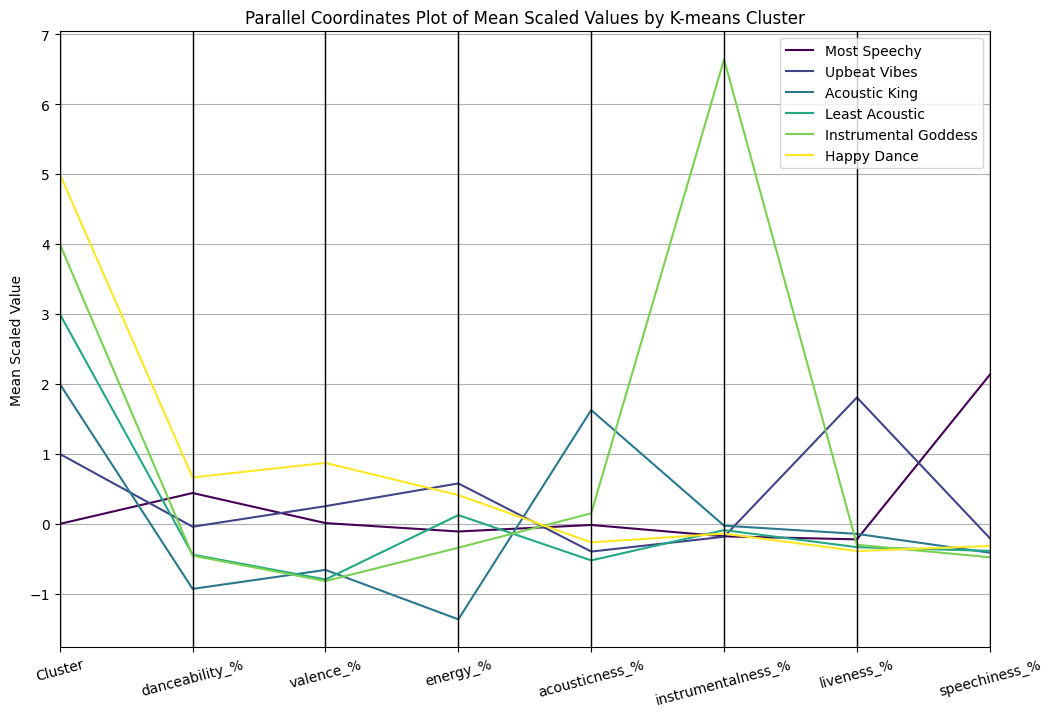

In [95]:
# Parallel Coordinates Plot for K-means clusters
# Use the dataframe with K-means cluster assignments on scaled data (df_scaled_kmeans_input)
# The cluster assignments are in the 'Cluster' column of this DataFrame.
cols_for_plotting_kmeans = cols_for_clustering + ['Cluster'] # cols_for_clustering is already defined

# To get a better sense of the cluster profiles, calculate the mean
# of the scaled variables for each K-means cluster.
# Group by the 'Cluster' column in df_scaled_kmeans_input
cluster_means_scaled_kmeans = df_scaled_kmeans_input.groupby('Cluster')[cols_for_clustering].mean()

print("\nMean of Scaled Variables per K-means Cluster:")
print(cluster_means_scaled_kmeans)

# Add cluster counts for K-means clusters
cluster_counts_kmeans = df_scaled_kmeans_input['Cluster'].value_counts().sort_index()
print("\nNumber of Data Points per K-means Cluster:")
print(cluster_counts_kmeans)

# Define custom names for the K-means clusters based on analysis in the previous markdown cell
# Make sure the keys match the cluster numbers (0, 1, 2, 3, 4, 5)
kmeans_cluster_names = {
    0: 'Most Speechy',
    1: 'Upbeat Vibes',
    2: 'Acoustic King',
    3: 'Least Acoustic',
    4: 'Instrumental Goddess',
    5: 'Happy Dance'
}

# Add a column with the custom cluster names to the cluster_means_scaled_kmeans DataFrame
# Map the cluster numbers (index) to the custom names
cluster_means_scaled_kmeans['Cluster_Name'] = cluster_means_scaled_kmeans.index.map(kmeans_cluster_names)

# We can visualize these means on a parallel coordinates plot
plt.figure(figsize=(12, 8))
# Use cluster_means_scaled_kmeans and the 'Cluster_Name' column for the class
parallel_coordinates(cluster_means_scaled_kmeans.reset_index(), 'Cluster_Name', colormap=plt.get_cmap("viridis"))

plt.title('Parallel Coordinates Plot of Mean Scaled Values by K-means Cluster')
plt.ylabel('Mean Scaled Value')
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

**Answer:** Cluster 0 has the highest point of speechiness but lacks in many other attributes, particularly in energy and liveness. Cluster 0 will be named as **"Most Speechy"**. Cluster 1 is the most lively and energetic but lacks acousticness. It will be known as **"Upbeat Vibes"**. Cluster 2 has the lowest energy levels but the highest acousticness and will be known as **"Acoustic King"**. Cluster 3 has very low attribute points overall; specifically, it is the lowest in acousticness values. It will be named **"Least Acoustic"**. Cluster 4 has an overwhelming score of instrumentalness, meaning it is by far the most instrumental cluster of them all but low in valence. It will be known as the **"Instrumental Goddess"**. Cluster 5, the final cluster, is high in danceability and valence but, interestingly enough, is lowest in liveness. It will be known as **"Happy Dance"**.



**4b:** Produce row level parallel plots for each cluster and the biplot of the clusters.  Describe the observable variability within the clusters and between the clusters.

View merge distances and the corresponding number of clusters. Going off of this data, the dendrogram will be formed.

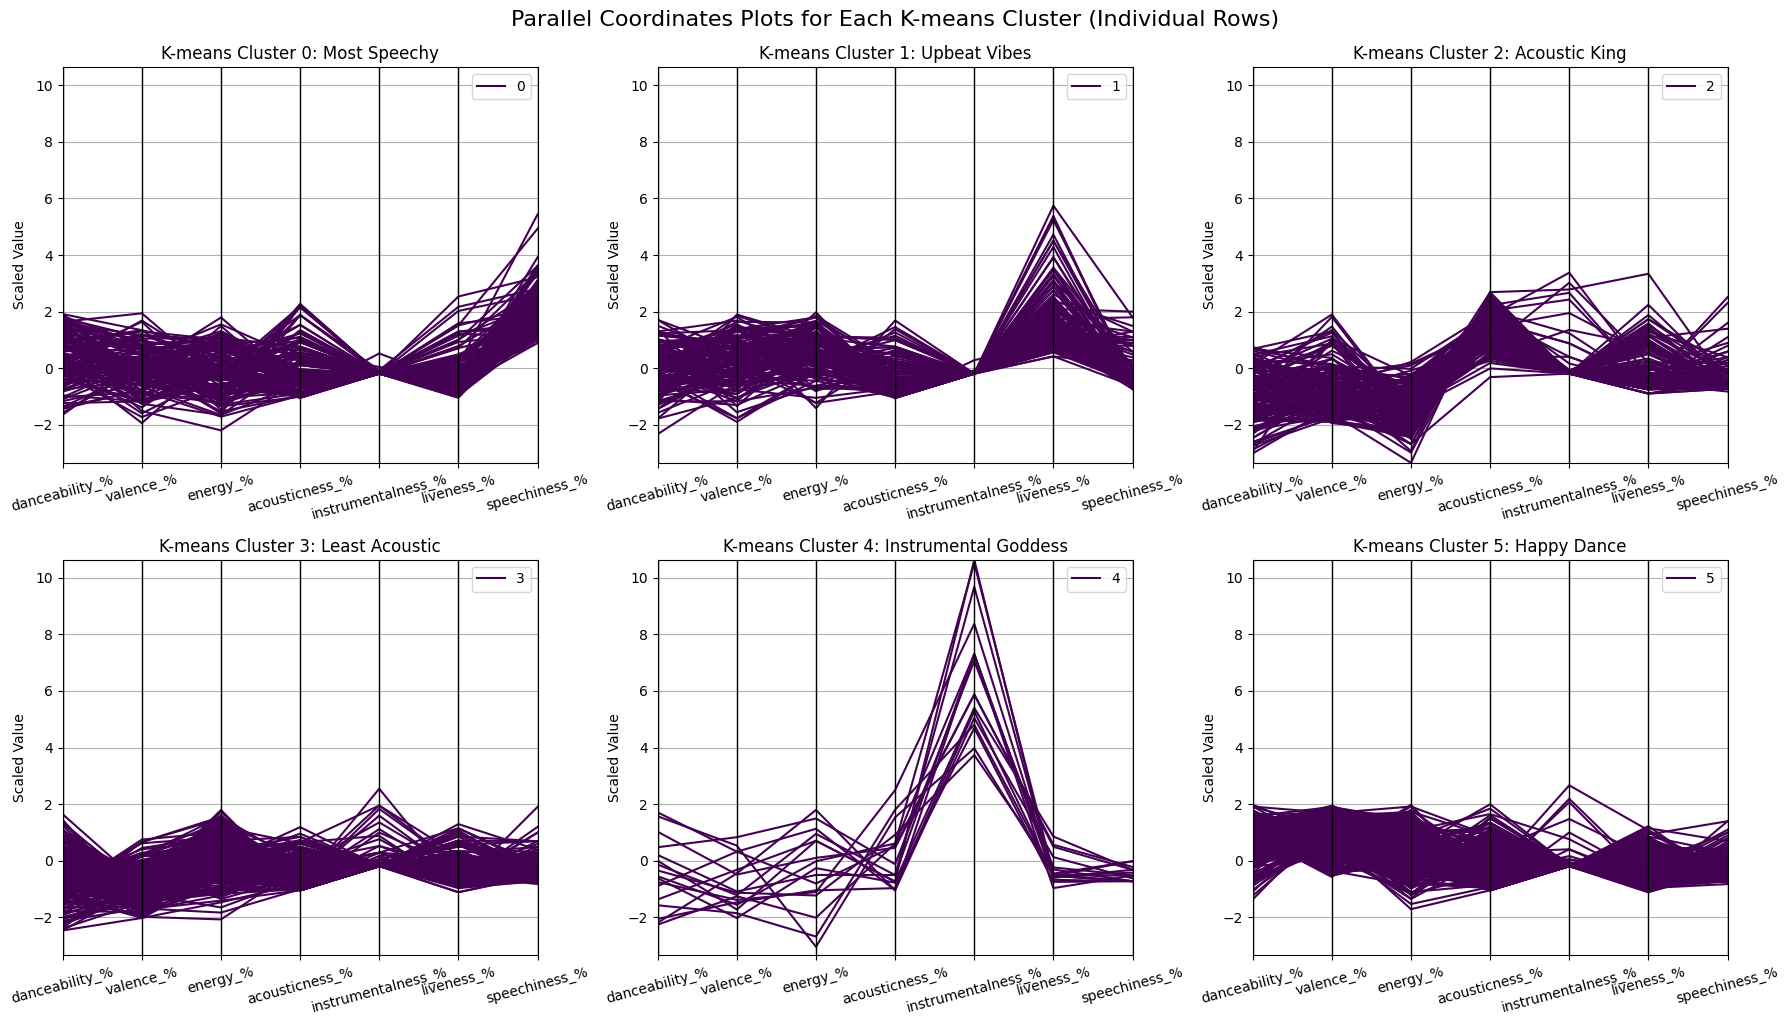

In [96]:
# To plot individual rows for each cluster, we need to select the columns for plotting,
# including the assigned 'Cluster' column from the K-means results.
cols_for_plotting_individual_kmeans = cols_for_clustering + ['Cluster']
# Use the dataframe with K-means cluster assignments on scaled data (df_scaled_kmeans_input)
df_plot_individual_kmeans = df_scaled_kmeans_input[cols_for_plotting_individual_kmeans].copy()

# We need to handle the index for the parallel coordinates plot function
# parallel_coordinates expects the 'class' column to be separate
# Let's iterate through each K-means cluster and create a separate plot

unique_clusters_kmeans = df_plot_individual_kmeans['Cluster'].unique()
unique_clusters_kmeans.sort() # Sort cluster numbers for order

# Determine the number of rows and columns for the subplot grid
n_clusters_kmeans = len(unique_clusters_kmeans)
n_cols_kmeans = 3 # Keep 3 columns as before
n_rows_kmeans = (n_clusters_kmeans + n_cols_kmeans - 1) // n_cols_kmeans # Calculate number of rows needed

# Create a single figure with subplots
fig_kmeans, axes_kmeans = plt.subplots(n_rows_kmeans, n_cols_kmeans, figsize=(n_cols_kmeans * 6, n_rows_kmeans * 5)) # Adjust figsize as needed
axes_kmeans = axes_kmeans.flatten() # Flatten the axes array for easier iteration

# Determine the global minimum and maximum values across all features and all data points for consistent y-axis
# Use the scaled data that was input to K-means for consistent scaling
global_min_kmeans = df_scaled_kmeans_input[cols_for_clustering].values.min()
global_max_kmeans = df_scaled_kmeans_input[cols_for_clustering].values.max()

# Define custom names for the K-means clusters based on analysis in the previous markdown cell
# Make sure the keys match the cluster numbers (0, 1, 2, 3, 4, 5)
kmeans_cluster_names = {
    0: 'Most Speechy',
    1: 'Upbeat Vibes',
    2: 'Acoustic King',
    3: 'Least Acoustic',
    4: 'Instrumental Goddess',
    5: 'Happy Dance'
}


for i, cluster_id_kmeans in enumerate(unique_clusters_kmeans):
    # Filter the dataframe for the current K-means cluster
    df_cluster_subset_kmeans = df_plot_individual_kmeans[df_plot_individual_kmeans['Cluster'] == cluster_id_kmeans].copy()

    # The 'class' column (Cluster) needs to be the last column for parallel_coordinates
    # and we need to ensure the data columns are in the correct order
    data_cols_kmeans = cols_for_clustering # Ensure data columns are in the original order
    df_cluster_subset_kmeans = df_cluster_subset_kmeans[data_cols_kmeans + ['Cluster']]

    # Plot parallel coordinates for the individual rows in this K-means cluster on the current subplot
    # Use a colormap suitable for categorical data if needed, or keep viridis
    parallel_coordinates(df_cluster_subset_kmeans, 'Cluster', colormap=plt.get_cmap("viridis"), ax=axes_kmeans[i])

    # Set the title using the custom cluster names
    axes_kmeans[i].set_title(f'K-means Cluster {cluster_id_kmeans}: {kmeans_cluster_names.get(cluster_id_kmeans, "Unknown Cluster")}')
    axes_kmeans[i].set_ylabel('Scaled Value')
    axes_kmeans[i].tick_params(axis='x', rotation=15)
    axes_kmeans[i].grid(True)
    axes_kmeans[i].set_ylim(global_min_kmeans, global_max_kmeans) # Set the same y-axis limits for all subplots


# Hide any unused subplots
for j in range(i + 1, len(axes_kmeans)):
    fig_kmeans.delaxes(axes_kmeans[j])

plt.tight_layout() # Adjust layout to prevent titles/labels overlapping
plt.suptitle('Parallel Coordinates Plots for Each K-means Cluster (Individual Rows)', y=1.02, fontsize=16) # Add a main title
plt.show()

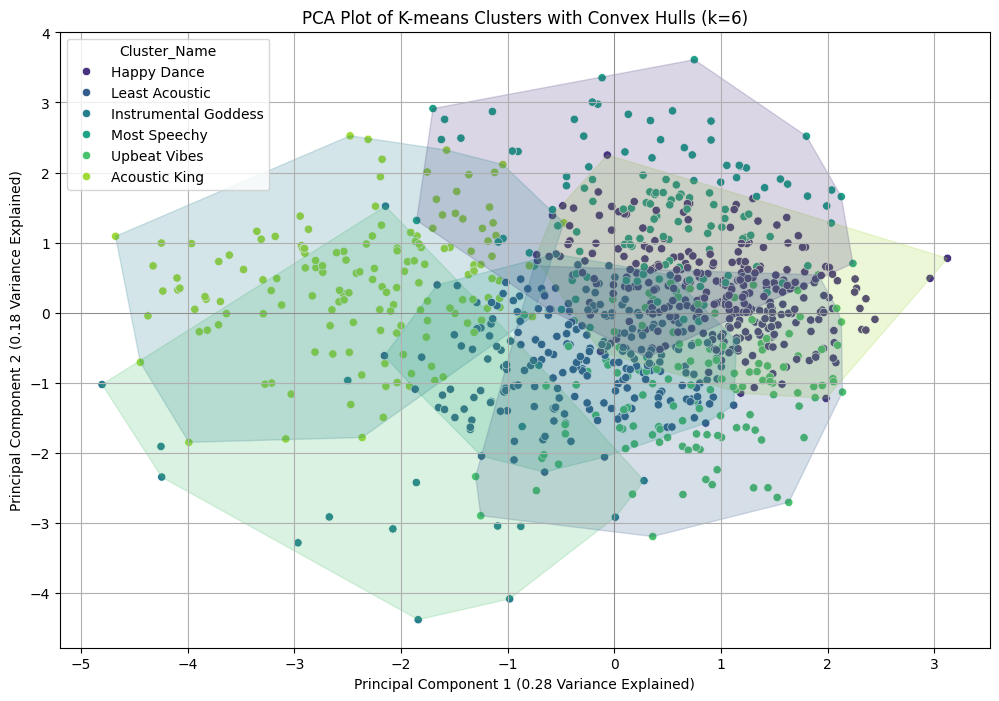

In [97]:
# Biplots using Principal Component Analysis (PCA) for K-means clusters
# This helps visualize K-means clusters in a reduced-dimensional space.

from sklearn.decomposition import PCA
import matplotlib.patches as patches # Import patches for drawing polygons
from scipy.spatial import ConvexHull # Import ConvexHull


# Use the scaled data that was input to K-means clustering
# This is df_scaled_kmeans_input, which already has the 'Cluster' column from K-means results
# We need to drop the 'Cluster' column before performing PCA
df_scaled_kmeans_pca_input = df_scaled_kmeans_input.drop(columns=['Cluster'])


# Perform PCA - let's keep 2 components for a 2D biplot
pca_kmeans = PCA(n_components=2)
principal_components_kmeans = pca_kmeans.fit_transform(df_scaled_kmeans_pca_input)

# Create a DataFrame with the principal components
df_principal_components_kmeans = pd.DataFrame(data=principal_components_kmeans, columns=['principal_component_1', 'principal_component_2'])

# Add the K-means cluster labels to the PCA dataframe
# Ensure the index aligns with the original scaled data before PCA
df_principal_components_kmeans['Cluster'] = df_scaled_kmeans_input['Cluster']

# Define custom names for the K-means clusters based on analysis in the previous markdown cell
# Make sure the keys match the cluster numbers (0, 1, 2, 3, 4, 5)
kmeans_cluster_names = {
    0: 'Most Speechy',
    1: 'Upbeat Vibes',
    2: 'Acoustic King',
    3: 'Least Acoustic',
    4: 'Instrumental Goddess',
    5: 'Happy Dance'
}

# Add a column with the custom cluster names to the PCA dataframe for plotting
df_principal_components_kmeans['Cluster_Name'] = df_principal_components_kmeans['Cluster'].map(kmeans_cluster_names)

# --- Plotting the Biplot ---

plt.figure(figsize=(12, 8))
ax_kmeans = plt.gca() # Get the current axes for adding patches

# Create a scatter plot of the data points in the PCA space, colored by K-means cluster name for the legend
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='Cluster_Name', data=df_principal_components_kmeans, palette='viridis', legend='full', ax=ax_kmeans)

# Add Convex Hulls for each K-means cluster
for cluster_id_kmeans in df_principal_components_kmeans['Cluster'].unique():
    # Filter data for the current K-means cluster
    cluster_data_kmeans = df_principal_components_kmeans[df_principal_components_kmeans['Cluster'] == cluster_id_kmeans]

    if len(cluster_data_kmeans) >= 3: # Need at least 3 points to form a polygon
        # Get the points for the convex hull
        points_kmeans = cluster_data_kmeans[['principal_component_1', 'principal_component_2']].values

        # Calculate the convex hull
        hull_kmeans = ConvexHull(points_kmeans)

        # Get the vertices of the convex hull in order
        hull_points_kmeans = points_kmeans[hull_kmeans.vertices]

        # Add the polygon patch for the convex hull
        polygon_kmeans = patches.Polygon(hull_points_kmeans,
                                  color=sns.color_palette('viridis', n_colors=len(df_principal_components_kmeans['Cluster'].unique()))[cluster_id_kmeans], # Get color based on cluster_id
                                  alpha=0.2, fill=True)

        # Add the polygon to the plot
        ax_kmeans.add_patch(polygon_kmeans)
    elif len(cluster_data_kmeans) > 0: # Handle clusters with 1 or 2 points (cannot form a hull)
         print(f"K-means Cluster {cluster_id_kmeans} has {len(cluster_data_kmeans)} points and cannot form a Convex Hull.")


plt.title('PCA Plot of K-means Clusters with Convex Hulls (k=6)') # Updated title and k value
plt.xlabel(f'Principal Component 1 ({pca_kmeans.explained_variance_ratio_[0]:.2f} Variance Explained)')
plt.ylabel(f'Principal Component 2 ({pca_kmeans.explained_variance_ratio_[1]:.2f} Variance Explained)')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.show()

**Answer:** *Within clusters*, Clusters 3 and 5 (Most Speechy and Acoustic King, respectively) have the least variability, while Cluster 4, Instrumental Goddess, has the most variability. *Between clusters*, Clusters 0 through 3 (Happy Dance through Most Speechy) have the most overlap in variability.

**Prompt 5:** Which clustering technique has yielded better results?  Explain your choice.

**Answer:** The hierarchical clustering technique has yielded better results because it was able to effectively create clusters that are more condensed in a lesser amount of clusters compared to the K-means clustering technique, as seen in the parallel coordinates plot (including for individual rows), as well as the PCA cluster plots for both types of clustering techniques. This implies that there is less variability within a cluster, indicating the clusters have more meaningful data compared to a K-means clustering technique.

**Prompt 6:** Save the cluster assignments back to the dataset for the chosen technique.

In [98]:
# Save the hierarchical cluster assignments back to the original dataframe
df['Hierarchical_Cluster'] = df_scaled_clustering['Cluster']

# Print the head of the dataframe to verify the new column
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_year  released_month  released_day  in_spotify_playlists  \
0           2023               7            14                   553   
1           2023               3            23                  1474   
2           2023               6            30                  1397   
3           2019               8            23                  7858   
4           2023               5            18                  3133   

   in_spotify_charts    streams  in_apple_playlists  in_apple_charts  \
0                147  141381703                  4

**Prompt 7:** Make box plots showing the distribution of streams by cluster.  Pretend you are a data scientist doing consulting work for a music producer.  If the producer’s biggest motivation is to generate revenue from streaming platforms, what cluster should you recommend?  What song attributes go along with that cluster?

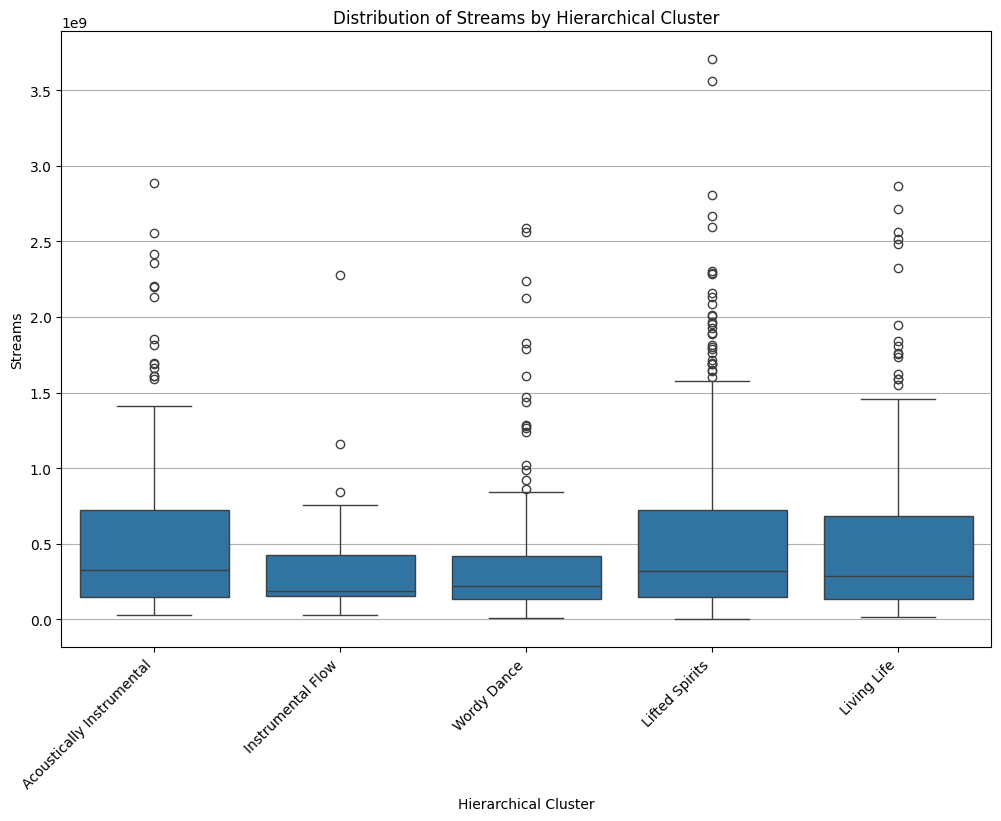


Descriptive Statistics of Streams by Hierarchical Cluster:
                      count          mean           std         min  \
Hierarchical_Cluster                                                  
1.0                   146.0  5.596704e+08  6.084606e+08  30546883.0   
2.0                    29.0  3.908953e+08  4.599316e+08  32761689.0   
3.0                   139.0  4.114311e+08  5.002158e+08  11956641.0   
4.0                   391.0  5.520187e+08  5.912810e+08      2762.0   
5.0                   246.0  5.011655e+08  5.425208e+08  14780425.0   

                               25%          50%           75%           max  
Hierarchical_Cluster                                                         
1.0                   1.466571e+08  329085383.0  7.250322e+08  2.887242e+09  
2.0                   1.543570e+08  185392587.0  4.274860e+08  2.280566e+09  
3.0                   1.360750e+08  223064273.0  4.199607e+08  2.591224e+09  
4.0                   1.494852e+08  323455692.0  7.2

In [99]:
plt.figure(figsize=(12, 8))
# Use the cluster numbers directly in the boxplot
sns.boxplot(x='Hierarchical_Cluster', y='streams', data=df)

# Add titles and labels
plt.title('Distribution of Streams by Hierarchical Cluster')
plt.xlabel('Hierarchical Cluster')
plt.ylabel('Streams')
plt.grid(axis='y')

# Define custom names for the hierarchical clusters
hierarchical_cluster_names = {
    1.0: 'Acoustically Instrumental',
    2.0: 'Instrumental Flow',
    3.0: 'Wordy Dance',
    4.0: 'Lifted Spirits',
    5.0: 'Living Life'
}

# Get the current axes
ax = plt.gca()

# Get the unique cluster values from the data that was plotted
# Sort them to ensure the labels match the boxes
unique_clusters_plotted = sorted(df['Hierarchical_Cluster'].dropna().unique())

# Create a list of the custom names in the order of the unique clusters plotted
custom_labels = [hierarchical_cluster_names.get(cluster_id, f'Cluster {int(cluster_id)}') for cluster_id in unique_clusters_plotted]

# Set the tick locations and labels
ax.set_xticks(range(len(unique_clusters_plotted))) # Set tick locations based on the number of unique clusters
ax.set_xticklabels(custom_labels, rotation=45, ha='right') # Set custom labels


plt.show()

# View the descriptive statistics of streams for each cluster
print("\nDescriptive Statistics of Streams by Hierarchical Cluster:")
print(df.groupby('Hierarchical_Cluster')['streams'].describe())

# View the mean attribute values for each hierarchical cluster
print("\nMean of Scaled Attributes by Hierarchical Cluster:")
print(cluster_means_scaled[cols_for_clustering])

**Answer:** If I were a data scientist doing consulting work for a music producer, and the producer’s biggest motivation was to generate revenue from streaming platforms, I would recommend the Lifted Spirits cluster, as the song attributes that go with it would be valence, energy, and danceability.
